# Presenting the Knot CNN

Previously: You can start this section by uploading previously zip archive in /content

Update: Data access is an interchangeable module that (a) pulls your train/test split from the Hugging Face Hub when available, and/or (b) gracefully falls back to a local path/zip if preferred. 

Below is a lightweight pattern that keeps your notebook runnable both in Colab and on a local Mac, while staying extensible.

```
knot-cnn/
├─ .conda/
├─ .venv/
├─ configs/
│  └─ hf_knots.yaml
├─ data/
│  ├─ raw/knot-crossings@main
│  │  ├─ test/      
│  │  ├─ train/   
│  │  ├─ .gitattributes
│  │  └─ README.md    
├─ hf-env/
├─ knot_detector/ 
│  ├─ data/
│  │  ├─ __pycache__/
│  │  ├─ __init__.py
│  │  ├─ dataset.py
│  ├─ training/
│  │  ├─ __init__.py
│  │  ├─ loops.py
│  │  ├─ metrics.py
│  ├─ eval.py
│  ├─ models.py
│  ├─ train.py
│  └─ utils.py
├─ notebooks/
│  │  ├─ knot_detector.ipynb
│  │  └─ presentation.ipynb <-- the one we are working on, chatgpt!
├─ scripts/
│  ├─ count_dataset_stats.py
│  ├─ split_val.py
│  └─ sync_hf_data.py
├─ .gitignore
├─ LICENSE
├─ README.md
└─ requirements.txt
```

In [1]:
# Install requirements quietly using %pip (recommended in Jupyter)
try:
	get_ipython().run_line_magic('pip', 'install -q -r ../requirements.txt')
except Exception:
	# Fallback to shell command if %pip is not available
	import os
	os.system("pip install -q -r ../requirements.txt")

Note: you may need to restart the kernel to use updated packages.


In [1]:
import sys
print(f"Python version: {sys.version}")
print(f"Python executable: {sys.executable}")
print(f"Virtual environment: {sys.prefix}")

# Test the problematic import
try:
    import tarfile
    print("✅ tarfile module found!")
except ImportError as e:
    print(f"❌ tarfile import failed: {e}")

# Test torch import
try:
    import torch
    print(f"✅ torch imported successfully! Version: {torch.__version__}")
except ImportError as e:
    print(f"❌ torch import failed: {e}")

Python version: 3.13.7 (main, Aug 14 2025, 11:12:11) [Clang 17.0.0 (clang-1700.0.13.3)]
Python executable: /Users/annedranowski/HQ/🚀 Projects/Knot Detector/.venv/bin/python
Virtual environment: /Users/annedranowski/HQ/🚀 Projects/Knot Detector/.venv
✅ tarfile module found!
✅ torch imported successfully! Version: 2.8.0


## 0) One-time installs (Colab or first local run)

In [6]:
# If you're in Colab, run this once:
# !pip -q install "torch==2.*" "torchvision==0.*" datasets huggingface_hub hf_transfer
# Optional if the HF dataset is private:
# !huggingface-cli login


## 1) Imports, device helpers, and dataset utilities

In [10]:
import os, sys, zipfile, shutil, tempfile
from pathlib import Path
from typing import Optional, Tuple

os.environ.setdefault("HF_HUB_ENABLE_HF_TRANSFER", "1")  # speeds up HF downloads if hf_transfer is installed

import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from datasets import load_dataset, Image as HFImage

# ---- device & transforms ----
def pick_device() -> str:
    if torch.cuda.is_available(): return "cuda"
    if torch.backends.mps.is_available(): return "mps"
    return "cpu"

def build_transforms(img_size=480):
    return transforms.Compose([
        transforms.Resize((img_size, img_size)),
        transforms.ToTensor()
    ])

# ---- ImageFolder detection & loaders ----
def looks_like_imagefolder(root: Path) -> bool:
    train, test = root/"train", root/"test"
    if not (train.is_dir() and test.is_dir()): return False
    has_train_cls = any(p.is_dir() for p in train.iterdir())
    has_test_cls  = any(p.is_dir() for p in test.iterdir())
    return has_train_cls and has_test_cls

def build_loaders_from_imagefolder(data_root: Path, batch_size=32, num_workers=2, device="cpu"):
    tfs = build_transforms()
    train_ds = datasets.ImageFolder(data_root/"train", transform=tfs)
    test_ds  = datasets.ImageFolder(data_root/"test",  transform=tfs)
    pin = device.startswith("cuda")
    nw  = 0 if device.startswith("mps") else num_workers
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                              num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    test_loader  = DataLoader(test_ds, batch_size=batch_size, shuffle=False,
                              num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    return train_loader, test_loader, train_ds.classes

# ---- Zip safety + “find real dataset root” ----
def _is_within_directory(base: Path, target: Path) -> bool:
    try:
        target.resolve().relative_to(base.resolve())
        return True
    except ValueError:
        return False

def safe_extract(zip_path: Path, extract_to: Path) -> None:
    with zipfile.ZipFile(zip_path, "r") as zf:
        for m in zf.infolist():
            member_path = extract_to / m.filename
            if not _is_within_directory(extract_to, member_path):
                raise RuntimeError(f"Unsafe path in archive: {m.filename}")
        zf.extractall(extract_to)

def find_imagefolder_root(extract_root: Path) -> Path:
    """Return the dir (at or under extract_root) that has train/ and test/ with class subdirs."""
    if looks_like_imagefolder(extract_root):
        return extract_root
    # breadth-first: shallowest candidates first
    candidates = [p for p in extract_root.rglob("*") if p.is_dir()]
    candidates.sort(key=lambda p: len(p.relative_to(extract_root).parts))
    for p in candidates:
        if looks_like_imagefolder(p):
            return p
    raise FileNotFoundError("Could not find an ImageFolder (train/ + test/) in extracted archive.")

def extract_zip_to_imagefolder(zip_path: Path, dest_root: Path) -> Path:
    """
    Extract a dataset ZIP and normalize it so the result is:
        dest_root / {train,test}/<class>/
    Replaces dest_root if it exists. Returns dest_root.
    """
    dest_root = dest_root.resolve()
    if dest_root.exists():
        shutil.rmtree(dest_root)
    dest_root.mkdir(parents=True, exist_ok=True)

    with tempfile.TemporaryDirectory() as td:
        tmp = Path(td)
        safe_extract(zip_path, tmp)
        src_root = find_imagefolder_root(tmp)
        for sub in ("train", "test"):
            src = src_root / sub
            if src.is_dir():
                (dest_root / sub).mkdir(parents=True, exist_ok=True)
                for p in src.iterdir():
                    shutil.move(str(p), str(dest_root / sub / p.name))
    return dest_root

# ---- HF Parquet (fallback) ----
def build_datasets_from_hf_parquet(repo_id: str, revision: Optional[str]=None,
                                   image_key="image", label_key="label"):
    ds_train = load_dataset(repo_id, split="train", revision=revision)
    ds_test  = load_dataset(repo_id, split="test",  revision=revision)
    if not isinstance(ds_train.features[image_key], HFImage):
        ds_train = ds_train.cast_column(image_key, HFImage())
        ds_test  = ds_test.cast_column(image_key,  HFImage())
    tfs = build_transforms()
    def _transform(ex):
        ex[image_key] = tfs(ex[image_key])
        return ex
    ds_train.set_transform(_transform)
    ds_test.set_transform(_transform)
    feat = ds_train.features.get(label_key, None)
    class_names = getattr(feat, "names", None) if feat is not None else None
    return ds_train, ds_test, class_names

def build_loaders_from_hf_datasets(ds_train, ds_test, image_key="image", label_key="label",
                                   batch_size=32, shuffle=True):
    def collate(batch):
        xs = torch.stack([b[image_key] for b in batch])
        ys = torch.tensor([b[label_key] for b in batch], dtype=torch.long)
        return xs, ys
    train_loader = DataLoader(ds_train, batch_size=batch_size, shuffle=shuffle, collate_fn=collate)
    test_loader  = DataLoader(ds_test,  batch_size=batch_size, shuffle=False,   collate_fn=collate)
    if hasattr(ds_train.features[label_key], "names") and ds_train.features[label_key].names:
        class_names = list(ds_train.features[label_key].names)
    else:
        labels = sorted({int(r[label_key]) for r in ds_train})
        class_names = [str(i) for i in labels]
    return train_loader, test_loader, class_names


## 2) DataResolver tuned to your repo layout + Hugging Face ZIP

In [11]:
from huggingface_hub import snapshot_download, hf_hub_download

class DataResolver:
    """
    Order:
      1) Use local repo data at data/raw/knot-crossings@main/ (fastest)
      2) Download and extract a single ZIP from HF (fast)
      3) Snapshot from HF (slower if many small files)
    """
    def __init__(self, repo_id: str, hf_zip_filename: str, revision: Optional[str]=None, repo_type: str="dataset"):
        self.repo_id = repo_id
        self.hf_zip_filename = hf_zip_filename  # e.g., "knot_images_480.zip"
        self.revision = revision
        self.repo_type = repo_type
        self.local_candidates = [
            Path("data/raw/knot-crossings@main"),
            Path("../data/raw/knot-crossings@main"),
        ]

    def _try_local(self) -> Optional[Path]:
        for root in self.local_candidates:
            root = root.resolve()
            if looks_like_imagefolder(root):
                print(f"✅ Using local dataset at: {root}")
                return root
        return None

    def _try_zip_from_hf(self, extract_to: Path) -> Optional[Path]:
        try:
            print(f"⬇️  Downloading ZIP from HF: {self.repo_id}/{self.hf_zip_filename}")
            zip_path = hf_hub_download(
                repo_id=self.repo_id,
                filename=self.hf_zip_filename,
                repo_type=self.repo_type,
                revision=self.revision
            )
            dest_root = Path(extract_to)
            root = extract_zip_to_imagefolder(Path(zip_path), dest_root)
            print(f"✅ Using HF ZIP (extracted) at: {root}")
            return root
        except Exception as e:
            print(f"⚠️ HF ZIP download failed: {e}")
            return None

    def _snapshot(self) -> Optional[Path]:
        try:
            print(f"⬇️  Falling back to snapshot_download for {self.repo_id} (may take longer)...")
            repo_path = snapshot_download(
                repo_id=self.repo_id,
                repo_type=self.repo_type,
                revision=self.revision,
                allow_patterns=["train/**", "test/**"]
            )
            root = Path(repo_path)
            if looks_like_imagefolder(root):
                print(f"✅ Using HF snapshot at: {root}")
                return root
            for p in root.iterdir():
                if p.is_dir() and looks_like_imagefolder(p):
                    print(f"✅ Using HF snapshot subdir at: {p}")
                    return p
            print("⚠️ Snapshot downloaded but train/test not found.")
            return None
        except Exception as e:
            print(f"❌ snapshot_download failed: {e}")
            return None

    def resolve(self, prefer_zip=True, extract_to=Path("data/raw/knot-crossings@main")) -> Tuple[Optional[Path], Optional[str]]:
        root = self._try_local()
        if root: return root, "local"
        if prefer_zip:
            root = self._try_zip_from_hf(Path(extract_to))
            if root: return root, "hf_zip"
        root = self._snapshot()
        if root: return root, "hf_snapshot"
        return None, None


## 3) Choose Colab vs Local at runtime, then build DataLoaders

In [12]:
# --- settings you can tweak at the top of the nb ---
REPO_ID = "tr33hugg3r/knot-crossings"   # HF dataset
HF_ZIP_FILENAME = "knot_crossings_dataset.tar.gz" # <-- set to your actual uploaded ZIP name
REVISION = None                         # optional: tag/commit
BATCH_SIZE = 32
NUM_WORKERS = 2

DEVICE = pick_device()
print("Device:", DEVICE)

# Try local/zip/snapshot in that order
resolver = DataResolver(repo_id=REPO_ID, hf_zip_filename=HF_ZIP_FILENAME, revision=REVISION)
data_root, source = resolver.resolve(prefer_zip=True, extract_to=Path("data/raw/knot-crossings@main"))

if data_root is not None:
    train_loader, test_loader, class_names = build_loaders_from_imagefolder(
        data_root, batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, device=DEVICE
    )
    print(f"Data source: {source}")
else:
    print("ℹ️ No ImageFolder found; falling back to HF Parquet view.")
    ds_train, ds_test, _ = build_datasets_from_hf_parquet(REPO_ID, revision=REVISION)
    train_loader, test_loader, class_names = build_loaders_from_hf_datasets(
        ds_train, ds_test, batch_size=BATCH_SIZE
    )
    print("Data source: hf_parquet")

print("Classes:", class_names)
num_classes = len(class_names)


Device: mps
✅ Using local dataset at: /Users/annedranowski/HQ/🚀 Projects/Knot Detector/data/raw/knot-crossings@main
Data source: local
Classes: ['0', '10', '3', '4', '5', '6', '7', '8', '9']


## Data

The next cell defines a preprocessing pipeline:

1. Grayscale → ensures uniform 1-channel input regardless of source image color.
1. ToImage → converts PIL or numpy arrays into a torch.Tensor with shape (C, H, W).
1. ToDtype → converts to float32 and rescales to [0, 1].
1. invert → flips dark/light values; knots might be white-on-black instead of black-on-white after this.

This sets up the dataset object (data) with preprocessing, ready to be wrapped in a DataLoader for batching in training or evaluation

But first...

In [14]:
# === Preprocessing choices ===
IMG_SIZE = 480
USE_GRAYSCALE = False        # True → grayscale; False → RGB
GRAYSCALE_CHANNELS = 3       # if grayscale, set 1 (model expects 1ch) or 3 (replicate to 3ch)

# v2 transforms (work with PIL or Tensor)
from torchvision.transforms import v2

if USE_GRAYSCALE:
    data_transform = v2.Compose([
        v2.Grayscale(num_output_channels=GRAYSCALE_CHANNELS),
        v2.Resize((IMG_SIZE, IMG_SIZE)),
        v2.ToImage(),
        v2.ToDtype(torch.float32, scale=True),
        # v2.functional.invert,   # <-- uncomment if you want inverted intensities
    ])
else:
    data_transform = v2.Compose([
        v2.Resize((IMG_SIZE, IMG_SIZE)),
        v2.ToImage(),                            # to (C,H,W) tensor
        v2.ToDtype(torch.float32, scale=True),   # [0,1]
    ])

# === Build datasets/loaders directly from the ImageFolder root the resolver gave us ===
from torchvision import datasets
from torch.utils.data import DataLoader

if data_root is not None:
    # ImageFolder path resolved (local or HF ZIP)
    train_ds = datasets.ImageFolder(data_root / "train", transform=data_transform)
    test_ds  = datasets.ImageFolder(data_root / "test",  transform=data_transform)

    # MPS-friendly loader settings
    pin = DEVICE.startswith("cuda")
    nw  = 0 if DEVICE.startswith("mps") else NUM_WORKERS

    train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                              num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                              num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    class_names = train_ds.classes
else:
    # Parquet fallback path already produced loaders & class_names earlier
    pass

print("Found classes (lexicographic):", class_names)


Found classes (lexicographic): ['0', '10', '3', '4', '5', '6', '7', '8', '9']


In [17]:
# ---- Remap ImageFolder labels to numeric order; drop test-only classes by default ----
from copy import deepcopy

def _numeric_sorted(names):          # '10' properly comes after '9'
    return sorted(list(names), key=lambda s: int(s))

def _apply_target_remap(imagefolder_ds, old_to_new_idx):
    imagefolder_ds.target_transform = (lambda y, m=deepcopy(old_to_new_idx): m[y])

def _filter_imagefolder_to_classes(imagefolder_ds, keep_class_names):
    keep = set(keep_class_names)
    orig_class_to_idx = deepcopy(imagefolder_ds.class_to_idx)
    orig_idx_to_class = {v:k for k,v in orig_class_to_idx.items()}
    keep_old_idx = {orig_class_to_idx[c] for c in orig_class_to_idx if c in keep}

    new_samples = [(p,t) for (p,t) in imagefolder_ds.samples if t in keep_old_idx]
    imagefolder_ds.samples = new_samples
    imagefolder_ds.imgs = new_samples
    imagefolder_ds.targets = [t for _,t in new_samples]

    kept_sorted = _numeric_sorted(keep_class_names)
    imagefolder_ds.classes = kept_sorted
    imagefolder_ds.class_to_idx = {c:i for i,c in enumerate(kept_sorted)}

    old_to_new = {}
    for old_idx in keep_old_idx:
        cname = orig_idx_to_class[old_idx]
        new_idx = imagefolder_ds.class_to_idx[cname]
        old_to_new[old_idx] = new_idx
    return old_to_new

if data_root is not None:
    train_ds = train_loader.dataset
    test_ds  = test_loader.dataset

    # 1) Define numeric order from TRAIN (model’s label space)
    train_sorted  = _numeric_sorted(train_ds.classes)
    train_new_idx = {c:i for i,c in enumerate(train_sorted)}
    train_old2new = {train_ds.class_to_idx[c]: train_new_idx[c] for c in train_ds.classes}
    _apply_target_remap(train_ds, train_old2new)

    # 2) TODO: Align TEST to TRAIN; drop test-only classes (like '11' if train lacks it)
    DROP_TEST_ONLY_CLASSES = False
    extra_in_test = [c for c in test_ds.classes if c not in train_ds.classes]
    if extra_in_test and DROP_TEST_ONLY_CLASSES:
        print(f"Note: dropping test-only classes (not in train): {_numeric_sorted(extra_in_test)}")
        test_old2new_local = _filter_imagefolder_to_classes(test_ds, keep_class_names=train_ds.classes)
        test_remap = {old_idx: train_new_idx[test_ds.classes[new_idx]]
                      for old_idx, new_idx in test_old2new_local.items()}
        _apply_target_remap(test_ds, test_remap)
    else:
        # keep test-only classes (analysis-only; not compatible with CE loss against a train-only head)
        test_sorted  = _numeric_sorted(test_ds.classes)
        test_new_idx = {c:i for i,c in enumerate(test_sorted)}
        test_old2new = {test_ds.class_to_idx[c]: test_new_idx[c] for c in test_ds.classes}
        _apply_target_remap(test_ds, test_old2new)
        if extra_in_test:
            print("Warning: test has classes unseen in train:", _numeric_sorted(extra_in_test))

    class_names = train_sorted
    num_classes = len(class_names)
    print("Numeric class order:", class_names)


Numeric class order: ['0', '3', '4', '5', '6', '7', '8', '9', '10']


In [20]:
# Make both datasets display classes in numeric order (and keep labels consistent)
def normalize_class_attrs_numeric(train_ds, test_ds, drop_test_only=True):
    # TRAIN: compute numeric order and update attrs
    train_sorted = sorted(train_ds.classes, key=lambda s: int(s))
    train_new_map = {c: i for i, c in enumerate(train_sorted)}
    # (Targets already remapped via target_transform earlier)
    train_ds.classes = train_sorted
    train_ds.class_to_idx = train_new_map

    # TEST: align to TRAIN or keep its own numeric order
    if drop_test_only:
        # test_ds was filtered/remapped earlier; just copy train's numeric order for the kept set
        keep = set(train_sorted)
        test_sorted = [c for c in train_sorted if c in test_ds.classes]  # intersection, train-defined order
        test_new_map = {c: i for i, c in enumerate(test_sorted)}
        test_ds.classes = test_sorted
        test_ds.class_to_idx = test_new_map
    else:
        # keep all test classes; show them in numeric order
        test_sorted = sorted(test_ds.classes, key=lambda s: int(s))
        test_new_map = {c: i for i, c in enumerate(test_sorted)}
        test_ds.classes = test_sorted
        test_ds.class_to_idx = test_new_map

# call it:
normalize_class_attrs_numeric(train_loader.dataset, test_loader.dataset, drop_test_only=False)

# now this will print numeric order in both:
describe_loader(train_loader, "train_loader")
describe_loader(test_loader,  "test_loader")


train_loader: 9051 items | batches: 283 of 32
  classes (9): ['0', '3', '4', '5', '6', '7', '8', '9', '10']
test_loader: 47 items | batches: 2 of 32
  classes (9): ['0', '3', '4', '5', '6', '7', '8', '9', '10']


In [18]:
# ---- Describe current loaders (works for ImageFolder or Parquet) ----
import math

def describe_loader(loader, name="loader"):
    bs = getattr(loader, "batch_size", None)
    n_batches = len(loader)
    ds = loader.dataset
    n_items = len(ds)
    classes = getattr(ds, "classes", None)  # ImageFolder only
    print(f"{name}: {n_items} items | batches: {n_batches}" + (f" of {bs}" if bs else ""))
    if classes is not None:
        print(f"  classes ({len(classes)}): {classes}")

describe_loader(train_loader, "train_loader")
describe_loader(test_loader,  "test_loader")


train_loader: 9051 items | batches: 283 of 32
  classes (9): ['0', '10', '3', '4', '5', '6', '7', '8', '9']
test_loader: 47 items | batches: 2 of 32
  classes (9): ['0', '3', '4', '5', '6', '7', '8', '9', '10']


In [ ]:
from torch.utils.data import DataLoader

def rebuild_loaders(train_ds, test_ds, batch_size=32, num_workers=2, device=DEVICE):
    pin = device.startswith("cuda")
    nw  = 0 if device.startswith("mps") else num_workers
    train_ld = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                          num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    test_ld  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False,
                          num_workers=nw, pin_memory=pin, persistent_workers=(nw>0))
    return train_ld, test_ld

# Example: bump to 64 safely
# train_loader, test_loader = rebuild_loaders(train_loader.dataset, test_loader.dataset,
#                                             batch_size=64, num_workers=2, device=DEVICE)
# describe_loader(train_loader, "train_loader (rebuilt)")
# describe_loader(test_loader,  "test_loader (rebuilt)")


⚠️ Note: If you intend to evaluate in batches (not one image at a time), add batch_size=BATCH_SIZE to your test_dataloader

In [ ]:
# Check out what's inside the training dataloader
train_features_batch, train_labels_batch = next(iter(train_dataloader))
train_features_batch.shape, train_labels_batch.shape

In [ ]:
train_data[0]

In [ ]:
# show a sample
import matplotlib.pyplot as plt

random_idx = torch.randint(0, len(train_features_batch), size=[1]).item()
img, label = train_features_batch[random_idx], train_labels_batch[random_idx]
plt.imshow(img.squeeze(), cmap="gray")
plt.title(data.classes[label])
plt.axis("Off");
print(f"Image size: {img.shape}")
print(f"Label: {label}, label size: {label.shape}")
print(data.classes)

In [4]:
# device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu" # cuda is MUCH faster
device

NameError: name 'torch' is not defined

In [ ]:
import requests # to fetch a remote file via HTTP
from pathlib import Path # object-oriented path handling

# Download helper functions from Learn PyTorch repo (if not already downloaded)
if Path("helper_functions.py").is_file():
  print("helper_functions.py already exists, skipping download")
else:
  print("Downloading helper_functions.py")
  request = requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py")
  with open("helper_functions.py", "wb") as f:
    f.write(request.content)

In [ ]:
if Path("helper_functions.py").is_file():
    print("helper_functions.py already exists, skipping download")
else:
    print("Downloading helper_functions.py")
    response = requests.get(
        "https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/helper_functions.py"
    )
    with open("helper_functions.py", "wb") as f:
        f.write(response.content)

In [ ]:
# aka training loop
def train_step(model: torch.nn.Module,
               data_loader: torch.utils.data.DataLoader,
               loss_fn: torch.nn.Module,
               optimizer: torch.optim.Optimizer,
               accuracy_fn,
               device: torch.device = device):
    train_loss, train_acc = 0, 0
    y_pred_train, y_target_train = [], []
    for (X, y) in data_loader:
        # Send data to GPU
        X, y = X.to(device), y.to(device)

        # 1. Forward pass
        y_pred = model(X).squeeze(dim=1)

        for i in y_pred.tolist():
          y_pred_train.append(round(i))
        for i in y.tolist():
          y_target_train.append(round(i))

        # 2. Calculate loss
        loss = loss_fn(y_pred, y.type(torch.float32))
        train_loss += loss
        train_acc += accuracy_fn(y_true=y,
                                 y_pred=y_pred.round()) # Go from logits -> pred labels

        # 3. Optimizer zero grad
        optimizer.zero_grad()

        # 4. Loss backward
        loss.backward()

        # 5. Optimizer step
        optimizer.step()

    # Calculate loss and accuracy per epoch and print out what's happening
    train_loss /= len(data_loader)
    train_acc /= len(data_loader)
    print(f"\nTrain loss: {train_loss:.5f} | Train accuracy: {train_acc:.2f}%")
    return y_pred_train, y_target_train, train_loss.cpu().detach().numpy(), train_acc

# aka testing loop
def test_step(data_loader: torch.utils.data.DataLoader,
              model: torch.nn.Module,
              loss_fn: torch.nn.Module,
              accuracy_fn,
              threshold: float = 0.001,
              device: torch.device = device,
              scheduler: torch.optim.lr_scheduler = None,
              save_path: str = None):
    test_loss, test_acc = 0, 0
    y_pred_test, y_target_test = [], []
    model.eval() # put model in eval mode
    # Turn on inference context manager
    with torch.inference_mode():
        for X, y in data_loader:
            # Send data to GPU
            X, y = X.to(device), y.to(device)

            # 1. Forward pass
            test_pred = model(X).squeeze(dim=1)

            for i in test_pred.tolist():
              y_pred_test.append(round(i))
            for i in y.tolist():
              y_target_test.append(round(i))

            # 2. Calculate loss and accuracy
            test_loss += loss_fn(test_pred, y.type(torch.float32))
            test_acc += accuracy_fn(y_true=y,
                y_pred=test_pred.round() # Go from logits -> pred labels
            )

        # Adjust metrics and print out
        test_loss /= len(data_loader)
        test_acc /= len(data_loader)

        if scheduler != None:
          scheduler.step(test_loss)

        if test_acc > best_acc:
          best_fold = fold
          if save_path != None:
            torch.save(model.state_dict(), save_path + f'{model.__class__.__name__}_best.pth')

        print(f"\nTest loss: {test_loss:.5f} | Test accuracy: {test_acc:.2f}%\n")
        return y_pred_test, y_target_test, test_loss.cpu().detach().numpy(), test_acc

GPT fixed eval_model below so that it has

- Correct dtypes: casts targets to float (your training uses MSE; this matches it).
- Extensible predictions: pred_fn lets you swap rounding for argmax if you switch to multiclass later: pred_fn=lambda z: z.argmax(dim=1). 
- Device hygiene: non-blocking transfers enabled. 
- Return is pure floats: easy logging and JSON-safe.

In [ ]:
# import torch
# from typing import Callable, Optional, Dict

def eval_model(
    model: torch.nn.Module,
    data_loader: torch.utils.data.DataLoader,
    loss_fn: torch.nn.Module,
    accuracy_fn: Callable,
    device: torch.device = torch.device("cpu"),
    *,
    pred_fn: Optional[Callable[[torch.Tensor], torch.Tensor]] = None
) -> Dict[str, float]:
    """
    Evaluate `model` on `data_loader`.

    Parameters
    ----------
    model : nn.Module
        Model to evaluate.
    data_loader : DataLoader
        Batches of (inputs, targets).
    loss_fn : nn.Module
        Loss function (e.g., MSELoss, CrossEntropyLoss).
    accuracy_fn : Callable
        Function taking (y_true, y_pred) and returning accuracy (%) as a float or scalar tensor.
    device : torch.device
        Compute device.
    pred_fn : Optional[Callable]
        Optional function to convert raw logits to predictions for accuracy.
        Defaults to rounding (binary-style) on squeezed logits.

    Returns
    -------
    dict
        {
          "model_name": str,
          "model_loss": float,   # averaged over batches
          "model_acc":  float    # averaged over batches
        }
    """
    model.eval()
    loss_sum, acc_sum = 0.0, 0.0

    if pred_fn is None:
        # Default: binary-style predictions via rounding after squeeze(1)
        def pred_fn_default(logits: torch.Tensor) -> torch.Tensor:
            if logits.ndim == 2 and logits.size(1) == 1:
                logits = logits.squeeze(1)
            return logits.round()
        pred_fn = pred_fn_default

    with torch.inference_mode():
        for X, y in data_loader:
            X = X.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            logits = model(X).squeeze(1)  # matches your current model/output usage

            # Ensure target dtype matches common regression/binary losses (MSE/BCE)
            target = y.float()

            batch_loss = loss_fn(logits, target)
            loss_sum += float(batch_loss.item())

            preds = pred_fn(logits)
            batch_acc = accuracy_fn(y_true=y, y_pred=preds)
            # support accuracy_fn returning tensor or float
            acc_sum += float(batch_acc if isinstance(batch_acc, float) else batch_acc.item())

    num_batches = len(data_loader)
    return {
        "model_name": model.__class__.__name__,
        "model_loss": loss_sum / num_batches,
        "model_acc":  acc_sum / num_batches,
    }


## Functions for plotting

- Reshape safety: Only reshapes linear weights to square when in_features is a perfect square; otherwise shows a 1×N heatmap instead of crashing.
- Type checks: Uses isinstance(layer, nn.Linear/nn.Conv2d).
- Normalization: Scales each map to [0,1] for consistent contrast.
- Titles: Each subplot shows original weight shape and final plotted shape.
- Compact demo tensor: Keeps your quick check but makes it shorter and more explicit.

TODO: Add an option to grid-plot multiple Conv2d filters (e.g., first 16 kernels of a chosen conv layer) instead of collapsing them—handy to inspect learned edge/texture detectors.

<!-- Extend this to grid plot multiple channels of a convolutional feature map (instead of collapsing with sum). That way you could see, for example, the first 16 filters’ activations separately. -->

In [ ]:
# --- Optional: tiny demo tensor (kept concise) ---
te = torch.arange(1., 10.).repeat(3, 1)   # shape [3, 9]
te = te.sum(dim=0)                        # [9]
siz_te = int(math.isqrt(te.numel()))
if siz_te * siz_te == te.numel():
    te_img = te.view(siz_te, siz_te)      # [3,3]
else:
    te_img = te.unsqueeze(0)              # fallback
te_img, siz_te

In [ ]:
def _to_numpy_image(t: torch.Tensor):
    """Detach → CPU → (H,W) numpy, normalized to [0,1] for nicer plots."""
    with torch.no_grad():
        x = t.detach().cpu().float()
        # squeeze channel dims if any
        while x.dim() > 2:
            x = x.squeeze(0)
        if x.dim() == 1:  # 1D vector → show as row
            x = x.unsqueeze(0)
        # normalize to [0,1] (avoid div-by-zero)
        mn, mx = x.min(), x.max()
        if (mx - mn) > 0:
            x = (x - mn) / (mx - mn)
        return x.numpy()

def _linear_to_spatial(weight: torch.Tensor):
    """
    Best-effort: sum over out_features, yielding a vector of length in_features.
    If it's a perfect square, reshape to (S,S); else return 1xN map.
    """
    # weight: [out_features, in_features]
    vec = weight.sum(dim=0)  # [in_features]
    n = vec.numel()
    s = int(math.isqrt(n))
    if s * s == n:
        return vec.view(s, s)
    else:
        # fallback: 1xN "image" so it's still plottable
        return vec.view(1, n)


def _conv_to_spatial(weight: torch.Tensor):
    """
    Collapse Conv2d filters to a single spatial map:
    sum over out_channels and in_channels -> [kh, kw].
    """
    # weight: [out_channels, in_channels, kh, kw]
    return weight.sum(dim=(0, 1))  # [kh, kw]

In [ ]:
# shows a visualization of the weights themselves (kernels or linear filters)
def plot_weights(layers, *, cmap="gray"):
    """
    Visualize weights for a list of layers.
    - nn.Linear: sums over out_features → tries to square-reshape.
    - nn.Conv2d: sums over out/in channels → spatial kernel.
    """
    if not isinstance(layers, (list, tuple)) or len(layers) == 0:
        raise ValueError("`layers` must be a non-empty list/tuple of modules.")

    fig, axs = plt.subplots(nrows=len(layers), ncols=1, figsize=(7, 4*len(layers)))
    if len(layers) == 1:
        axs = [axs]

    for ax, layer in zip(axs, layers):
        if isinstance(layer, nn.Linear):
            spatial = _linear_to_spatial(layer.weight)
            title = f"Linear {tuple(layer.weight.shape)} → {tuple(spatial.shape)}"
        elif isinstance(layer, nn.Conv2d):
            spatial = _conv_to_spatial(layer.weight)
            title = f"Conv2d {tuple(layer.weight.shape)} → {tuple(spatial.shape)}"
        else:
            ax.axis("off")
            ax.set_title(f"Unsupported layer type: {layer.__class__.__name__}")
            continue

        img = _to_numpy_image(spatial)
        ax.imshow(img, cmap=cmap, interpolation="nearest")
        ax.set_title(title)
        ax.axis("off")

    plt.tight_layout()
    plt.show()

In [ ]:
# shows what happens when you pass an input image through each layer in sequence, plotting the resulting feature maps:
# Take a list of layers (or all Conv/Linear layers in your model).
# Forward the input image through the first func_length layers.
# After each layer, collect the transformed output (activation/feature map).
# Plot those activations as images, so you can see how the representation evolves.
def plot_weights_image(layers: list, func_length: int, img: torch.Tensor, cmap="gray"):
    """
    Passes an input image through the first `func_length` layers
    and plots the resulting feature maps.

    Parameters
    ----------
    layers : list[nn.Module]
        Sequence of layers (e.g., from model.named_modules()).
    func_length : int
        How many layers to include from the list.
    img : torch.Tensor
        Input image tensor of shape [C, H, W] or [1, C, H, W].
    cmap : str
        Colormap for plotting grayscale feature maps.
    """
    model_layers = layers[:func_length]

    # Ensure batch dimension
    if img.ndim == 3:  # [C, H, W]
        x = img.unsqueeze(0)
    else:
        x = img.clone()

    fig, axs = plt.subplots(1, func_length, figsize=(4*func_length, 4))

    if func_length == 1:
        axs = [axs]

    for i, (ax, layer) in enumerate(zip(axs, model_layers)):
        x = layer(x)

        # Handle Conv/Linear separately (linear → flatten)
        if isinstance(layer, nn.Linear):
            feature_map = x.detach().cpu().view(1, -1)  # show as 1×N
        else:
            # collapse channel dim by summing <-- 
            feature_map = x.detach().cpu().sum(dim=1).squeeze()

        ax.imshow(feature_map.numpy(), cmap=cmap)
        ax.set_title(f"Layer {i}: {layer.__class__.__name__}")
        ax.axis("off")

    plt.tight_layout()
    plt.show()

### Example Usage

In [ ]:
# Grab Conv/Linear layers from model_2
to_be_shown = (nn.Conv2d, nn.Linear)
layers = [m for _, m in model_2.named_modules() if isinstance(m, to_be_shown)]
count = len(layers)

# Pick a sample image from your dataset
sample_img, _ = next(iter(train_dataloader))
sample_img = sample_img[0].to(device)  # [1, H, W]

# Plot through first few layers
plot_weights_image(layers, func_length=5, img=sample_img)

## Building the CNN

<!-- - No brittle flatten math: nn.LazyBatchNorm1d() and nn.LazyLinear(4096) infer the correct in_features automatically.
- Consistent formatting & comments: easier to read and tune.
- Inplace ReLU: slight memory win without changing behavior.
- Clear usage notes: explains how to set output_shape based on task. -->

1. Defines the CNN (KnotsModelCNN)

    - TinyVGG-style feature extractor (5 conv blocks) → classifier with big FC layers.
    - Uses Lazy layers in the classifier to avoid hard-coding the flatten size.

2. Instantiates and inspects the model

    - Builds model_2 = KnotsModelCNN(output_shape=1).to(device).
    - Prints trainable parameter count and an approx. memory size (params+buffers).

3. Sets up training

    - Loss: MSELoss (treats the task as regression-to-class).
    - Optimizer: AdamW; Scheduler: ReduceLROnPlateau (monitoring validation loss).
    - Tracking containers for losses/accuracies and per-epoch predictions/targets.

4. Runs training (loop #1)

    - Epoch loop over EPOCHS=30.
    - Calls train_step then test_step (used here as validation), prints LR and metrics.
    - Early-stops if val accuracy ≥ 99.9%.

5. Runs training again (loop #2, inside while p:)

    - Re-initializes a new model and repeats the entire training setup with EPOCHS=20, retraining from scratch until the 99.9% threshold is hit.
    - Ends with the same metric plots (loss + accuracy curves).

6. Plots metrics

Side-by-side loss and accuracy curves over epochs.

In [ ]:
# import torch
# from torch import nn

class KnotsModelCNN(nn.Module):
    """
    TinyVGG-like CNN for knot-crossing prediction.

    Notes
    -----
    - Input:  (N, 1, H, W) grayscale images
    - Output: logits of shape (N, output_shape)
      * For classification: set output_shape = num_classes and use CrossEntropyLoss.
      * For regression-style counting: set output_shape = 1 and use MSE/BCE as desired.
    - Uses Lazy layers to avoid hardcoding the flatten dimension.
    """

    def __init__(self, output_shape: int, dropout: float = 0.7):
        super().__init__()

        # --- Feature extractor ---
        self.conv_1 = nn.Sequential(
            nn.Conv2d(1,   4,  kernel_size=11, stride=1, dilation=2, padding=0),
            nn.BatchNorm2d(4),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(4,  16,  kernel_size=5,  stride=1, dilation=2, padding=0),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 64,  kernel_size=3,  stride=1, dilation=2, padding=0),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 256, kernel_size=3,  stride=1, dilation=2, padding=0),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(256, 361, kernel_size=3, stride=1, padding=0),
            nn.BatchNorm2d(361),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        # --- Classifier (flatten → FCs) ---
        # Lazy layers infer the in_features at first forward pass, so you don't need to hardcode 361*(12)**2.
        # Consider smaller than 4096->4096 FCs or Global Average Pooling to reduce parameter count. It's a trade-off between model size and performance. 4096->4096 is large for 1-channel 480×480 inputs. 
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.LazyBatchNorm1d(),
            nn.Dropout(p=dropout),

            nn.LazyLinear(4096),
            nn.BatchNorm1d(4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=dropout),

            nn.Linear(4096, 4096),
            nn.ReLU(inplace=True),

            nn.Linear(4096, output_shape),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        x = self.conv_1(x)
        x = self.classifier(x)
        return x


Re Lazy layers + parameter counting above: nn.Lazy* modules don’t initialize shapes until the first forward pass. Counting params before the first forward will under-report (often zero for lazy layers). TODO: Run a dummy forward once (e.g., one batch) before calling count_trainable_params / model_size_mb.

In [ ]:
# --- Instantiate model ---
model_2 = KnotsModelCNN(output_shape=1).to(device)

# --- Utilities ---
def count_trainable_params(model) -> int:
    """Number of trainable parameters."""
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

def model_size_mb(model) -> float:
    """Approximate model size in MB (parameters + buffers)."""
    param_bytes  = sum(p.nelement() * p.element_size() for p in model.parameters())
    buffer_bytes = sum(b.nelement() * b.element_size() for b in model.buffers())
    return (param_bytes + buffer_bytes) / (1024 ** 2)

# --- Report ---
n_params = count_trainable_params(model_2)
size_mb  = model_size_mb(model_2)

print(f"Trainable parameters: {n_params:,}")
print(f"Approx. model size  : {size_mb:.3f} MB")


Re Scheduler stepping location & LR reporting below: ReduceLROnPlateau should step after you compute validation loss (you pass the scheduler into test_step; that’s okay if test_step calls scheduler.step(valid_loss)). scheduler.get_last_lr() may not exist on older versions and isn’t very meaningful for RoP; read LR from the optimizer param group instead. TODO: After validation: scheduler.step(valid_loss). To print LR: optimizer.param_groups[0]['lr'].

In [ ]:
# --- Loss, Optimizer, Scheduler ---
loss_fn = nn.MSELoss()  # NOTE: treating this as regression-to-class; CrossEntropy for multiclass classification too strict 

optimizer = torch.optim.AdamW(
    model_2.parameters(),
    lr=3e-4,
    weight_decay=1e-4
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",     # track validation loss
    factor=0.2,     # reduce LR by 5x on plateau
    patience=2,     # wait 2 epochs without improvement
    threshold=1e-3  # minimal improvement to count
)

# --- Tracking containers ---
train_losses, train_accuracies = [], []
valid_losses, valid_accuracies = [], []
y_pred_train, y_target_train = [], []
y_pred_valid, y_target_valid = [], []

# --- Training config ---
from pathlib import Path
from helper_functions import accuracy_fn
from tqdm.notebook import tqdm

EPOCHS = 30
SAVE_PATH = Path("content/saved_models")
SAVE_PATH.mkdir(parents=True, exist_ok=True)

# --- Epoch loop ---
for epoch in tqdm(range(EPOCHS), desc="Training"):
    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    # ReduceLROnPlateau updates after validation; here we just *report* current LR
    try:
        print(f"LR: {scheduler.get_last_lr()}")
    except AttributeError:
        # Older PyTorch may not have get_last_lr on this scheduler; safe to skip
        pass

    # Train
    y_pred_train, y_target_train, train_loss, train_acc = train_step(
        data_loader=train_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        optimizer=optimizer,
        accuracy_fn=accuracy_fn,
    )
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    # Validate (NOTE: validation and test use different data; keep test pristine for final reporting)
    # TODO: Use a true validation loader (split from train) and reserve test for final evaluation. Rename variables to avoid confusion.
    y_pred_valid, y_target_valid, valid_loss, valid_acc = test_step(
        data_loader=test_dataloader,
        model=model_2,
        loss_fn=loss_fn,
        accuracy_fn=accuracy_fn,
        scheduler=scheduler  # ReduceLROnPlateau steps inside test_step using valid_loss
    )
    valid_losses.append(valid_loss)
    valid_accuracies.append(valid_acc)

    # Free up VRAM (no-op on CPU)
    torch.cuda.empty_cache()

    # Very aggressive early stopping on accuracy threshold
    # TODO: Use a patience-based early stopping on val loss or choose a more realistic accuracy target.
    if valid_acc >= 99.9:
        print(f"Early stopping at epoch {epoch+1} (val_acc={valid_acc:.2f}%)")
        break


Above: full training loop (EPOCHS=30). Below: another inside while loop (EPOCHS=20) that recreates the model and trains again. 

TODO: Keep one training run with early stopping. If you want “restart until threshold,” only keep the while p: block; otherwise delete it.

Also above and below: calling torch.cuda.empty_cache() every epoch is slow. Remove it unless you’re fighting fragmentation on small GPUs.

In [ ]:
# from pathlib import Path
# from tqdm.notebook import tqdm
# from helper_functions import accuracy_fn

p = True  # keep training fresh models until threshold met

while p:
    # --- Model & training setup ---
    model_2 = KnotsModelCNN(output_shape=1).to(device)

    loss_fn = nn.MSELoss()  # regression-to-class; consider CrossEntropy for multiclass
    optimizer = torch.optim.AdamW(model_2.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="min", factor=0.2, patience=2, threshold=1e-3
    )

    # --- Tracking ---
    train_losses, train_accuracies = [], []
    valid_losses, valid_accuracies = [], []
    y_pred_train, y_target_train = [], []
    y_pred_valid, y_target_valid = [], []

    EPOCHS = 20
    SAVE_PATH = Path("content/saved_models")
    SAVE_PATH.mkdir(parents=True, exist_ok=True)

    # --- Epoch loop ---
    for epoch in tqdm(range(EPOCHS), desc="Training"):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        try:
            print(f"LR: {scheduler.get_last_lr()}")  # ReduceLROnPlateau exposes last LR in recent PyTorch
        except AttributeError:
            pass

        # Train
        y_pred_train, y_target_train, train_loss, train_acc = train_step(
            data_loader=train_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            optimizer=optimizer,
            accuracy_fn=accuracy_fn,
        )
        train_losses.append(train_loss)
        train_accuracies.append(train_acc)

        # Validate (NOTE: val ≠ test; keep test for final reporting)
        y_pred_valid, y_target_valid, valid_loss, valid_acc = test_step(
            data_loader=test_dataloader,
            model=model_2,
            loss_fn=loss_fn,
            accuracy_fn=accuracy_fn,
            scheduler=scheduler,  # steps on val loss inside test_step
        )
        valid_losses.append(valid_loss)
        valid_accuracies.append(valid_acc)

        torch.cuda.empty_cache()

        # Early stop + exit the outer loop if threshold reached
        if valid_acc >= 99.9:
            print(f"Early stopping at epoch {epoch+1} (val_acc={valid_acc:.2f}%).")
            p = False
            break


Below: Use range(1, len(train_losses)+1) for x-axis instead of EPOCHS, in case early stopping triggers, lengths of train_losses/valid_losses < EPOCHS.

NameError: name 'EPOCHS' is not defined

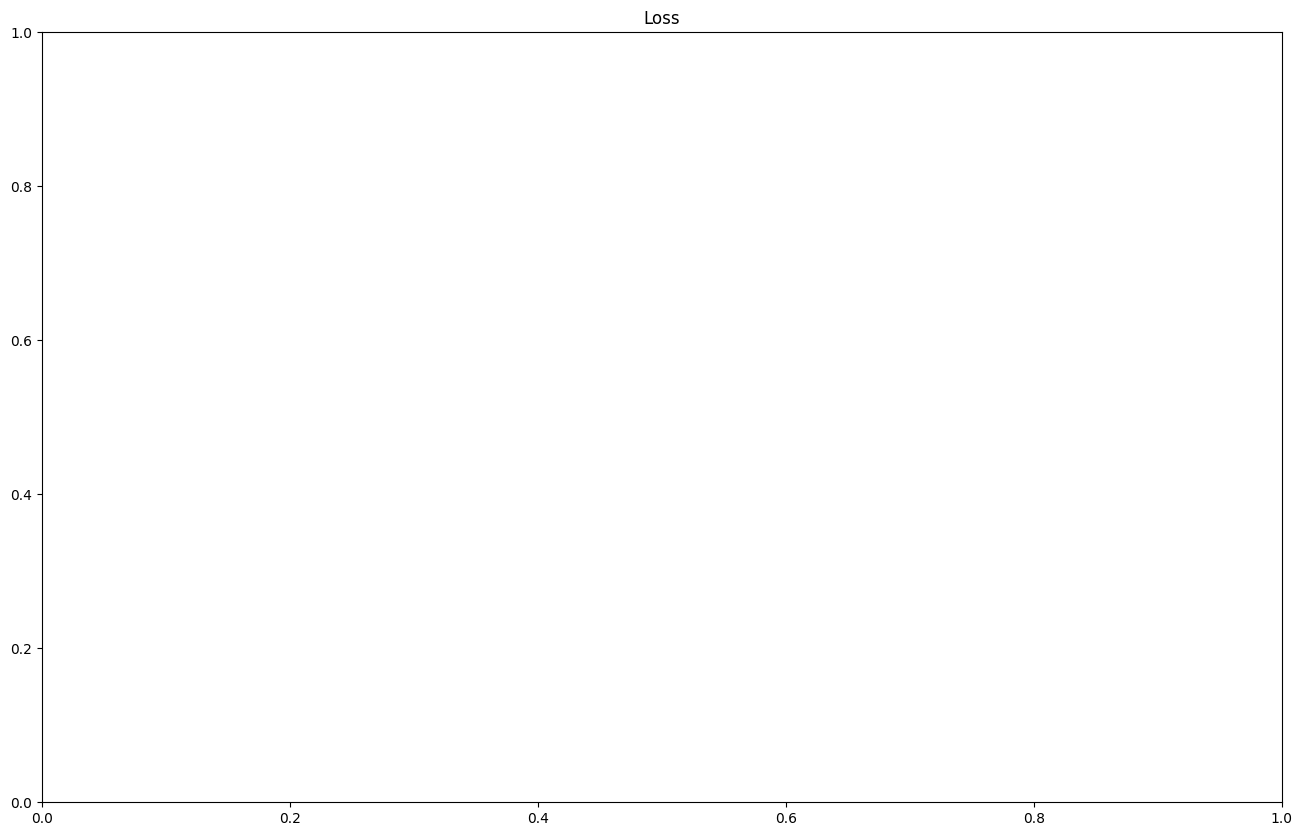

In [ ]:
# --- Plot training & validation metrics ---
epochs = range(1, EPOCHS + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Loss curves
ax1.plot(epochs, train_losses, label="Train Loss", linewidth=2)
ax1.plot(epochs, valid_losses, label="Validation Loss", linewidth=2)
ax1.set_title("Training vs Validation Loss", fontsize=14)
ax1.set_xlabel("Epoch", fontsize=12)
ax1.set_ylabel("Loss", fontsize=12)
ax1.legend()
ax1.grid(True, linestyle="--", alpha=0.6)

# Accuracy curves
ax2.plot(epochs, train_accuracies, label="Train Accuracy", linewidth=2)
ax2.plot(epochs, valid_accuracies, label="Validation Accuracy", linewidth=2)
ax2.set_title("Training vs Validation Accuracy", fontsize=14)
ax2.set_xlabel("Epoch", fontsize=12)
ax2.set_ylabel("Accuracy (%)", fontsize=12)
ax2.legend()
ax2.grid(True, linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


## Visualizing accuracy

Plotting confusion matrices alongside accuracy scores.

In [ ]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

# --- 1) Compute confusion matrices for train/validation ---
labels = list(range(len(data.classes)))  # numeric class labels (e.g., 0–11)

conf_matrix_train = confusion_matrix(y_target_train, y_pred_train, labels=labels)
conf_matrix_valid = confusion_matrix(y_target_valid, y_pred_valid, labels=labels)

# --- 2) Compute additional metrics ---
# Average = "macro" gives equal weight to each class (better with class imbalance)
train_acc = accuracy_score(y_target_train, y_pred_train)
train_prec = precision_score(y_target_train, y_pred_train, average="macro", zero_division=0)
train_rec  = recall_score(y_target_train, y_pred_train, average="macro", zero_division=0)
train_f1   = f1_score(y_target_train, y_pred_train, average="macro", zero_division=0)

valid_acc = accuracy_score(y_target_valid, y_pred_valid)
valid_prec = precision_score(y_target_valid, y_pred_valid, average="macro", zero_division=0)
valid_rec  = recall_score(y_target_valid, y_pred_valid, average="macro", zero_division=0)
valid_f1   = f1_score(y_target_valid, y_pred_valid, average="macro", zero_division=0)

print("Train metrics:")
print(f"  Accuracy : {train_acc:.3f}")
print(f"  Precision: {train_prec:.3f}")
print(f"  Recall   : {train_rec:.3f}")
print(f"  F1-score : {train_f1:.3f}")

print("\nValidation metrics:")
print(f"  Accuracy : {valid_acc:.3f}")
print(f"  Precision: {valid_prec:.3f}")
print(f"  Recall   : {valid_rec:.3f}")
print(f"  F1-score : {valid_f1:.3f}")

# --- 3) Plot side-by-side confusion matrices ---
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ConfusionMatrixDisplay(conf_matrix_train, display_labels=data.classes).plot(
    ax=ax1, cmap="Blues", colorbar=False
)
ConfusionMatrixDisplay(conf_matrix_valid, display_labels=data.classes).plot(
    ax=ax2, cmap="Blues", colorbar=False
)

ax1.set_title("Train Confusion Matrix")
ax2.set_title("Validation Confusion Matrix")
plt.tight_layout()
plt.show()


## Visualizing model weights and a sample input

- Plot selected layer weights from your CNN.
- Display a random training image for context.
- Collect a set of layers of interest (Conv/Linear) and then visualize the effect of those layers on the sample image via plot_weights_image.

### 1) Manually picks specific layers and calls your plot_weights(...) helper to visualize their kernels/weights.

In [ ]:
# --- 1) Visualize selected layer weights (manual pick) ---
layers_to_plot = [
    model_2.conv_1[0],
    model_2.conv_1[4],
    model_2.conv_1[8],
    model_2.conv_1[12],
    model_2.conv_1[16],
    model_2.classifier[3],
    model_2.classifier[7],
    model_2.classifier[9],
]
plot_weights(layers_to_plot)

### 2) Samples one image from the already-fetched batch train_features_batch, plots it in grayscale.

In [ ]:
# --- 2) Show a random training image from the current batch ---
idx = torch.randint(len(train_features_batch), (1,)).item()
img = train_features_batch[idx]                      # shape: [1, H, W]
plt.imshow(img.squeeze(), cmap="gray")
plt.axis("off")
plt.show()

### 3) Walks the model and gathers all non-top-level modules into layers.

Filters layers to Conv2d/Linear only

In [ ]:
# --- 3) Collect Conv/Linear layers only (for pipeline viz) ---
to_be_shown = (nn.Conv2d, nn.Linear)
layers = [m for _, m in model_2.named_modules() if isinstance(m, to_be_shown)]
count = len(layers)

# If plot_weights_image expects (layers, count, image), use the filtered list:
plot_weights_image(layers, count, img)


## Evaluating and saving the model

This is the final workflow chunk for saving, loading, evaluating, and testing the CNN. One pass to save, reload cleanly, eval on val, eval on test, and run a quick inference, without duplicated steps or redefined transforms.

### 1. Evaluate current model on validation set

* Runs evaluation on the validation dataloader.
* Prints results (loss, accuracy, etc.).

In [ ]:
# --- 1) Evaluate current model on *validation* set ---
# NOTE: Validation and test use different data; keep test untouched for final reporting.
model_2_val_results = eval_model(
    model=model_2,
    data_loader=valid_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
model_2_val_results


### 2. Save the model weights, again

* Creates a `models/` directory.
* Saves the current model_2 weights to models/CNN.pth.

<!-- 👉 You only need one load–save–reload cycle (or just load once). -->

In [ ]:
# --- 2) Save trained weights (single, canonical location) ---
MODEL_PATH = Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_SAVE_PATH = MODEL_PATH / "CNN.pth"

print(f"Saving model to: {MODEL_SAVE_PATH}")
torch.save(model_2.state_dict(), MODEL_SAVE_PATH)


### 3. Instantiate a fresh model and reload weights

- Recreates the model with the same architecture.
- Loads saved weights into it.
- Sanity check: prints model summary and verifies device.
- Finally, assigns back: `model_2 = loaded_model_2`

<!-- 👉 First you load into model_2, then later overwrite it with loaded_model_2. Only one is necessary. -->

In [ ]:
# --- 3) Recreate a fresh model and load weights ---
loaded_model_2 = KnotsModelCNN(
    hidden_units_conv=2,
    hidden_units_fc=1024,
    output_shape=1
).to(device)

state_dict = torch.load(MODEL_SAVE_PATH, map_location=device)
loaded_model_2.load_state_dict(state_dict)

print(f"Loaded weights from: {MODEL_SAVE_PATH}")
print(f"Model device: {next(loaded_model_2.parameters()).device}")

# (Optionally replace the original handle so subsequent cells use the loaded model)
model_2 = loaded_model_2


### 4. Evaluate trained model on test set

Evaluates the reloaded model on the test data.

<!-- 👉 You evaluate on valid_dataloader before reloading, and again on test_dataloader after. That’s fine logically (val vs test), but if both use the same data, it’s redundant. -->

In [ ]:
# --- 4) Evaluate loaded model on *test* set (final/unbiased) ---
model_2_test_results = eval_model(
    model=model_2,
    data_loader=test_dataloader,
    loss_fn=loss_fn,
    accuracy_fn=accuracy_fn,
    device=device
)
model_2_test_results


### 5. Run inference on sample images

- Defines preprocessing (grayscale → float → invert).
- Loads two sample images, transforms them, batches them.
- Feeds them through the trained model to get predictions.

<!-- 👉 The preprocessing pipeline is re-declared here, but you already had one earlier for training/validation. You could reuse the same transform instead of redefining. -->

In [ ]:
# --- 5) Quick inference on a few sample images (reuses existing data_transform) ---
# Assumes `data_transform` and `device` are already defined earlier in the notebook.
# from PIL import Image
# import torch

sample_paths = ["/content/3_1.png", "/content/4_1.png"]
batch = torch.cat(
    [data_transform(Image.open(p)).unsqueeze(0).to(device) for p in sample_paths],
    dim=0
)  # [N, C, H, W]

outputs = model_2(batch)  # raw model outputs
outputs
